In [57]:
# ============================================================
# 0. INSTALACIÓN DE LIBRERÍAS
# ============================================================

!pip install folium imageio imageio[ffmpeg] seaborn -q

In [58]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import imageio.v2 as imageio

from IPython.display import display, Image, Video

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

In [59]:
# ============================================================
# 2. CONFIGURACIÓN GENERAL DEL CASO
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    "n_clientes": 24,
    "n_vehiculos": 4,
    "poblacion": 140,
    "generaciones": 180,
    "prob_mutacion": 0.25,
    "elite": 8,
    "torneo_k": 5,
    "hora_inicio": 8 * 60,
    "hora_fin": 18 * 60,
    "velocidad_kmh": 28,
    "tiempo_servicio_base": 12,
    "penalidad_capacidad": 1000,
    "penalidad_incompatibilidad": 900,
    "fps_video": 8,
    "frame_step": 3
}

OUTPUT_DIR = "resultados_vrp_lima"
FRAME_DIR = os.path.join(OUTPUT_DIR, "frames")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FRAME_DIR, exist_ok=True)

In [60]:
# ============================================================
# 3. FUNCIONES AUXILIARES
# ============================================================

def minutos_a_hora(minutos):
    horas = int(minutos // 60)
    mins = int(minutos % 60)
    return f"{horas:02d}:{mins:02d}"


def haversine_km(lat1, lon1, lat2, lon2):
    radio_tierra = 6371

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )

    return 2 * radio_tierra * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def km_a_minutos(km):
    return km / CONFIG["velocidad_kmh"] * 60

In [61]:
# ============================================================
# 4. DATOS REALISTAS DEL CASO
# ============================================================

deposito = {
    "nombre": "CD Santa Anita",
    "direccion": "Av. Nicolás Ayllón, Santa Anita, Lima",
    "lat": -12.0444,
    "lon": -76.9711
}

vehiculos = pd.DataFrame([
    {
        "vehiculo": "Camión 1",
        "placa": "B8Q-742",
        "tipo": "Furgón mediano",
        "capacidad_m3": 15,
        "disponible_desde": "08:00",
        "disponible_hasta": "18:00"
    },
    {
        "vehiculo": "Camión 2",
        "placa": "AJW-529",
        "tipo": "Furgón mediano",
        "capacidad_m3": 15,
        "disponible_desde": "08:00",
        "disponible_hasta": "18:00"
    },
    {
        "vehiculo": "Camión 3",
        "placa": "C7L-318",
        "tipo": "Unidad ligera",
        "capacidad_m3": 10,
        "disponible_desde": "08:00",
        "disponible_hasta": "18:00"
    },
    {
        "vehiculo": "Camión 4",
        "placa": "D2P-904",
        "tipo": "Unidad ligera",
        "capacidad_m3": 8,
        "disponible_desde": "08:00",
        "disponible_hasta": "18:00"
    }
])

clientes_base = [
    ("Universidad Norte", "Av. Universitaria, Los Olivos", "Los Olivos", -11.9580, -77.0660),
    ("Carpintería Comas", "Av. Túpac Amaru, Comas", "Comas", -11.9320, -77.0400),
    ("Decoraciones Mega", "Av. Carlos Izaguirre, Independencia", "Independencia", -11.9940, -77.0540),
    ("Muebles Perú Norte", "Av. Perú, San Martín de Porres", "San Martín de Porres", -12.0300, -77.0800),
    ("Obra Callao", "Av. Sáenz Peña, Callao", "Callao", -12.0560, -77.1180),
    ("Taller Bellavista", "Av. Venezuela, Bellavista", "Bellavista", -12.0620, -77.0880),
    ("Retail San Miguel", "Av. La Marina, San Miguel", "San Miguel", -12.0780, -77.0930),
    ("Carpintería Libre", "Av. Bolívar, Pueblo Libre", "Pueblo Libre", -12.0760, -77.0670),
    ("Proyecto JM", "Av. Salaverry, Jesús María", "Jesús María", -12.0750, -77.0480),
    ("Diseño Lince", "Av. Arequipa, Lince", "Lince", -12.0840, -77.0340),
    ("Oficinas SI", "Av. Javier Prado, San Isidro", "San Isidro", -12.0970, -77.0360),
    ("Showroom Miraflores", "Av. Larco, Miraflores", "Miraflores", -12.1210, -77.0300),
    ("Diseño Barranco", "Av. San Martín, Barranco", "Barranco", -12.1490, -77.0210),
    ("Constructora Surco", "Av. Primavera, Santiago de Surco", "Surco", -12.1450, -76.9910),
    ("Residencial Molina", "Av. La Molina, La Molina", "La Molina", -12.0870, -76.9280),
    ("Planta Ate", "Carretera Central, Ate", "Ate", -12.0450, -76.9000),
    ("Cliente Santa Anita", "Av. Los Ruiseñores, Santa Anita", "Santa Anita", -12.0430, -76.9710),
    ("Proyecto Agustino", "Av. Riva Agüero, El Agustino", "El Agustino", -12.0440, -77.0020),
    ("Obra SJL", "Av. Próceres, San Juan de Lurigancho", "San Juan de Lurigancho", -12.0000, -77.0100),
    ("Carpintería Chorrillos", "Av. Huaylas, Chorrillos", "Chorrillos", -12.1720, -77.0140),
    ("Proyecto VES", "Av. Revolución, Villa El Salvador", "Villa El Salvador", -12.2140, -76.9360),
    ("Taller VMT", "Av. Pachacútec, Villa María del Triunfo", "Villa María del Triunfo", -12.1600, -76.9430),
    ("Obra Lurín", "Antigua Panamericana Sur, Lurín", "Lurín", -12.2750, -76.8740),
    ("Proyecto Pachacámac", "Av. Paul Poblet, Pachacámac", "Pachacámac", -12.2300, -76.8600)
]

tipos_carga = ["Melamina", "MDF", "OSB", "Canteado frágil", "Adhesivos", "Herrajes pesados"]

ventanas = [
    (8 * 60, 11 * 60),
    (9 * 60, 13 * 60),
    (11 * 60, 15 * 60),
    (14 * 60, 17 * 60),
    (8 * 60, 16 * 60)
]

clientes_data = []

for i, item in enumerate(clientes_base):
    nombre, direccion, distrito, lat, lon = item

    demanda = np.random.uniform(0.8, 3.3)
    tipo_carga = np.random.choice(
        tipos_carga,
        p=[0.30, 0.22, 0.15, 0.15, 0.08, 0.10]
    )
    prioridad = np.random.choice(
        ["Normal", "Alta", "Crítica"],
        p=[0.55, 0.30, 0.15]
    )
    ventana_inicio, ventana_fin = random.choice(ventanas)

    clientes_data.append({
        "id": i,
        "cliente": nombre,
        "direccion": direccion,
        "distrito": distrito,
        "lat": lat + np.random.normal(0, 0.003),
        "lon": lon + np.random.normal(0, 0.003),
        "demanda_m3": round(demanda, 2),
        "tipo_carga": tipo_carga,
        "prioridad": prioridad,
        "ventana_inicio": ventana_inicio,
        "ventana_fin": ventana_fin,
        "ventana": f"{minutos_a_hora(ventana_inicio)} - {minutos_a_hora(ventana_fin)}"
    })

clientes = pd.DataFrame(clientes_data)

display(vehiculos)
display(clientes.head())

,vehiculo,placa,tipo,capacidad_m3,disponible_desde,disponible_hasta
0,Camión 1,B8Q-742,Furgón mediano,15,08:00,18:00
1,Camión 2,AJW-529,Furgón mediano,15,08:00,18:00
2,Camión 3,C7L-318,Unidad ligera,10,08:00,18:00
3,Camión 4,D2P-904,Unidad ligera,8,08:00,18:00


,id,cliente,direccion,distrito,lat,lon,demanda_m3,tipo_carga,prioridad,ventana_inicio,ventana_fin,ventana
0,0,Universidad Norte,"Av. Universitaria, Los Olivos",Los Olivos,-11.961336,-77.065043,1.74,Herrajes pesados,Alta,480,660,08:00 - 11:00
1,1,Carpintería Comas,"Av. Túpac Amaru, Comas",Comas,-11.927262,-77.037698,1.19,Melamina,Crítica,480,660,08:00 - 11:00
2,2,Decoraciones Mega,"Av. Carlos Izaguirre, Independencia",Independencia,-11.995743,-77.055576,0.85,Herrajes pesados,Alta,660,900,11:00 - 15:00
3,3,Muebles Perú Norte,"Av. Perú, San Martín de Porres",San Martín de Porres,-12.035175,-77.081687,1.26,MDF,Normal,540,780,09:00 - 13:00
4,4,Obra Callao,"Av. Sáenz Peña, Callao",Callao,-12.058110,-77.124419,2.33,Melamina,Normal,540,780,09:00 - 13:00


In [62]:
# ============================================================
# 5. MATRIZ DE DISTANCIAS
# ============================================================

coordenadas = [(deposito["lat"], deposito["lon"])] + list(zip(clientes["lat"], clientes["lon"]))

n_nodos = CONFIG["n_clientes"] + 1
dist_matrix = np.zeros((n_nodos, n_nodos))

for i in range(n_nodos):
    for j in range(n_nodos):
        dist_matrix[i, j] = haversine_km(
            coordenadas[i][0],
            coordenadas[i][1],
            coordenadas[j][0],
            coordenadas[j][1]
        )

In [63]:
# ============================================================
# 6. RESTRICCIONES DE COMPATIBILIDAD DE CARGA
# ============================================================

incompatibilidades = {
    ("Adhesivos", "Canteado frágil"),
    ("Herrajes pesados", "Canteado frágil"),
    ("Adhesivos", "Melamina")
}


def cargas_incompatibles(tipo_1, tipo_2):
    return (
        (tipo_1, tipo_2) in incompatibilidades
        or (tipo_2, tipo_1) in incompatibilidades
    )

In [64]:
# ============================================================
# 7. DECODIFICACIÓN DEL CROMOSOMA
# ============================================================

def decodificar_cromosoma(cromosoma):
    """
    El cromosoma es una permutación de clientes.
    Cada gen representa un cliente.
    La secuencia completa se divide entre vehículos según capacidad.
    """
    rutas = [[] for _ in range(CONFIG["n_vehiculos"])]
    cargas = [0.0 for _ in range(CONFIG["n_vehiculos"])]

    vehiculo_actual = 0

    for cliente_id in cromosoma:
        demanda = clientes.loc[cliente_id, "demanda_m3"]

        if cargas[vehiculo_actual] + demanda <= vehiculos.loc[vehiculo_actual, "capacidad_m3"]:
            rutas[vehiculo_actual].append(cliente_id)
            cargas[vehiculo_actual] += demanda

        else:
            if vehiculo_actual < CONFIG["n_vehiculos"] - 1:
                vehiculo_actual += 1

            rutas[vehiculo_actual].append(cliente_id)
            cargas[vehiculo_actual] += demanda

    return rutas

In [65]:
# ============================================================
# 8. FUNCIÓN OBJETIVO
# ============================================================

def evaluar_ruta(ruta, vehiculo_idx):
    if not ruta:
        return 0, {
            "distancia": 0,
            "penalizacion": 0,
            "carga": 0,
            "hora_retorno": CONFIG["hora_inicio"],
            "llegadas": [],
            "incompatibilidades": 0,
            "atraso_total": 0
        }

    distancia_total = 0
    penalizacion = 0
    tiempo = CONFIG["hora_inicio"]
    carga = clientes.loc[ruta, "demanda_m3"].sum()
    capacidad = vehiculos.loc[vehiculo_idx, "capacidad_m3"]

    if carga > capacidad:
        penalizacion += (carga - capacidad) * CONFIG["penalidad_capacidad"]

    tipos = list(clientes.loc[ruta, "tipo_carga"])
    incompatibilidades_detectadas = 0

    for i in range(len(tipos)):
        for j in range(i + 1, len(tipos)):
            if cargas_incompatibles(tipos[i], tipos[j]):
                incompatibilidades_detectadas += 1
                penalizacion += CONFIG["penalidad_incompatibilidad"]

    nodo_anterior = 0
    llegadas = []
    atraso_total = 0

    for cliente_id in ruta:
        nodo_cliente = cliente_id + 1

        distancia_tramo = dist_matrix[nodo_anterior, nodo_cliente]
        distancia_total += distancia_tramo
        tiempo += km_a_minutos(distancia_tramo)

        ventana_inicio = clientes.loc[cliente_id, "ventana_inicio"]
        ventana_fin = clientes.loc[cliente_id, "ventana_fin"]
        prioridad = clientes.loc[cliente_id, "prioridad"]

        if tiempo < ventana_inicio:
            tiempo = ventana_inicio

        atraso = max(0, tiempo - ventana_fin)
        atraso_total += atraso

        if prioridad == "Crítica":
            penalizacion += atraso * 12
        elif prioridad == "Alta":
            penalizacion += atraso * 7
        else:
            penalizacion += atraso * 4

        tiempo_servicio = (
            CONFIG["tiempo_servicio_base"]
            + clientes.loc[cliente_id, "demanda_m3"] * 3
        )

        llegadas.append({
            "cliente_id": cliente_id,
            "llegada": tiempo,
            "atraso": atraso
        })

        tiempo += tiempo_servicio
        nodo_anterior = nodo_cliente

    distancia_retorno = dist_matrix[nodo_anterior, 0]
    distancia_total += distancia_retorno
    tiempo += km_a_minutos(distancia_retorno)

    if tiempo > CONFIG["hora_fin"]:
        penalizacion += (tiempo - CONFIG["hora_fin"]) * 8

    costo = distancia_total + penalizacion

    detalle = {
        "distancia": distancia_total,
        "penalizacion": penalizacion,
        "carga": carga,
        "hora_retorno": tiempo,
        "llegadas": llegadas,
        "incompatibilidades": incompatibilidades_detectadas,
        "atraso_total": atraso_total
    }

    return costo, detalle


def fitness(cromosoma):
    rutas = decodificar_cromosoma(cromosoma)
    costo_total = 0

    for vehiculo_idx, ruta in enumerate(rutas):
        costo, _ = evaluar_ruta(ruta, vehiculo_idx)
        costo_total += costo

    return costo_total

In [66]:
# ============================================================
# 9. OPERADORES DEL ALGORITMO GENÉTICO
# ============================================================

def crear_individuo():
    individuo = list(range(CONFIG["n_clientes"]))
    random.shuffle(individuo)
    return individuo


def crear_poblacion():
    return [crear_individuo() for _ in range(CONFIG["poblacion"])]


def seleccion_torneo(poblacion):
    candidatos = random.sample(poblacion, CONFIG["torneo_k"])
    return min(candidatos, key=fitness)


def crossover_ordenado(padre_1, padre_2):
    n = len(padre_1)
    inicio, fin = sorted(random.sample(range(n), 2))

    hijo = [None] * n
    hijo[inicio:fin] = padre_1[inicio:fin]

    genes_faltantes = [gen for gen in padre_2 if gen not in hijo]
    idx = 0

    for i in range(n):
        if hijo[i] is None:
            hijo[i] = genes_faltantes[idx]
            idx += 1

    return hijo


def mutar(individuo):
    nuevo = individuo.copy()

    if random.random() < CONFIG["prob_mutacion"]:
        tipo = random.choice(["swap", "reverse", "insert"])

        if tipo == "swap":
            i, j = random.sample(range(len(nuevo)), 2)
            nuevo[i], nuevo[j] = nuevo[j], nuevo[i]

        elif tipo == "reverse":
            i, j = sorted(random.sample(range(len(nuevo)), 2))
            nuevo[i:j] = reversed(nuevo[i:j])

        elif tipo == "insert":
            i, j = random.sample(range(len(nuevo)), 2)
            gen = nuevo.pop(i)
            nuevo.insert(j, gen)

    return nuevo


def evolucionar_poblacion(poblacion):
    poblacion_ordenada = sorted(poblacion, key=fitness)
    nueva_poblacion = poblacion_ordenada[:CONFIG["elite"]]

    while len(nueva_poblacion) < CONFIG["poblacion"]:
        padre_1 = seleccion_torneo(poblacion)
        padre_2 = seleccion_torneo(poblacion)

        hijo = crossover_ordenado(padre_1, padre_2)
        hijo = mutar(hijo)

        nueva_poblacion.append(hijo)

    return nueva_poblacion

In [67]:
# ============================================================
# 10. SIMULACIÓN
# ============================================================

poblacion = crear_poblacion()

historial = {
    "generacion": [],
    "mejor_costo": [],
    "costo_promedio": [],
    "peor_costo": []
}

mejores_cromosomas = []

for gen in range(CONFIG["generaciones"] + 1):
    costos = np.array([fitness(ind) for ind in poblacion])

    mejor_idx = np.argmin(costos)
    mejor_individuo = poblacion[mejor_idx]

    historial["generacion"].append(gen)
    historial["mejor_costo"].append(costos.min())
    historial["costo_promedio"].append(costos.mean())
    historial["peor_costo"].append(costos.max())

    mejores_cromosomas.append(mejor_individuo.copy())

    if gen < CONFIG["generaciones"]:
        poblacion = evolucionar_poblacion(poblacion)

historial_df = pd.DataFrame(historial)

mejor_cromosoma = mejores_cromosomas[-1]
rutas_finales = decodificar_cromosoma(mejor_cromosoma)

print("Simulación terminada")
print(f"Costo inicial: {historial_df['mejor_costo'].iloc[0]:,.2f}")
print(f"Costo final: {historial_df['mejor_costo'].iloc[-1]:,.2f}")
print(f"Mejora: {(1 - historial_df['mejor_costo'].iloc[-1] / historial_df['mejor_costo'].iloc[0]) * 100:.2f}%")

Simulación terminada
Costo inicial: 5,781.56
Costo final: 244.02
Mejora: 95.78%


In [68]:
# ============================================================
# 11. REPORTES OPERATIVOS
# ============================================================

def generar_reportes(rutas):
    resumen_rutas = []
    detalle_entregas = []

    for vehiculo_idx, ruta in enumerate(rutas):
        costo, detalle = evaluar_ruta(ruta, vehiculo_idx)

        resumen_rutas.append({
            "vehiculo": vehiculos.loc[vehiculo_idx, "vehiculo"],
            "placa": vehiculos.loc[vehiculo_idx, "placa"],
            "tipo": vehiculos.loc[vehiculo_idx, "tipo"],
            "clientes": len(ruta),
            "carga_m3": round(detalle["carga"], 2),
            "capacidad_m3": vehiculos.loc[vehiculo_idx, "capacidad_m3"],
            "distancia_km": round(detalle["distancia"], 2),
            "penalizacion": round(detalle["penalizacion"], 2),
            "incompatibilidades": detalle["incompatibilidades"],
            "atraso_total_min": round(detalle["atraso_total"], 1),
            "hora_retorno": minutos_a_hora(detalle["hora_retorno"])
        })

        for parada, entrega in enumerate(detalle["llegadas"], start=1):
            cliente_id = entrega["cliente_id"]
            fila = clientes.loc[cliente_id]

            detalle_entregas.append({
                "vehiculo": vehiculos.loc[vehiculo_idx, "vehiculo"],
                "placa": vehiculos.loc[vehiculo_idx, "placa"],
                "orden": parada,
                "cliente": fila["cliente"],
                "direccion": fila["direccion"],
                "distrito": fila["distrito"],
                "tipo_carga": fila["tipo_carga"],
                "demanda_m3": fila["demanda_m3"],
                "prioridad": fila["prioridad"],
                "ventana": fila["ventana"],
                "llegada_estimada": minutos_a_hora(entrega["llegada"]),
                "atraso_min": round(entrega["atraso"], 1)
            })

    return pd.DataFrame(resumen_rutas), pd.DataFrame(detalle_entregas)


resumen_rutas_df, detalle_entregas_df = generar_reportes(rutas_finales)

display(resumen_rutas_df)
display(detalle_entregas_df)

,vehiculo,placa,tipo,clientes,carga_m3,capacidad_m3,distancia_km,penalizacion,incompatibilidades,atraso_total_min,hora_retorno
0,Camión 1,B8Q-742,Furgón mediano,9,14.14,15,67.54,0,0,0,15:36
1,Camión 2,AJW-529,Furgón mediano,6,12.89,15,65.40,0,0,0,12:10
2,Camión 3,C7L-318,Unidad ligera,5,8.67,10,44.23,0,0,0,11:00
3,Camión 4,D2P-904,Unidad ligera,4,6.15,8,66.84,0,0,0,15:33


,vehiculo,placa,orden,cliente,direccion,distrito,tipo_carga,demanda_m3,prioridad,ventana,llegada_estimada,atraso_min
0,Camión 1,B8Q-742,1,Carpintería Comas,"Av. Túpac Amaru, Comas",Comas,Melamina,1.19,Crítica,08:00 - 11:00,08:31,0
1,Camión 1,B8Q-742,2,Universidad Norte,"Av. Universitaria, Los Olivos",Los Olivos,Herrajes pesados,1.74,Alta,08:00 - 11:00,08:57,0
2,Camión 1,B8Q-742,3,Muebles Perú Norte,"Av. Perú, San Martín de Porres",San Martín de Porres,MDF,1.26,Normal,09:00 - 13:00,09:33,0
3,Camión 1,B8Q-742,4,Obra Callao,"Av. Sáenz Peña, Callao",Callao,Melamina,2.33,Normal,09:00 - 13:00,10:00,0
4,Camión 1,B8Q-742,5,Taller Bellavista,"Av. Venezuela, Bellavista",Bellavista,Melamina,2.76,Normal,09:00 - 13:00,10:27,0
5,Camión 1,B8Q-742,6,Proyecto JM,"Av. Salaverry, Jesús María",Jesús María,Herrajes pesados,0.89,Normal,08:00 - 11:00,10:58,0
6,Camión 1,B8Q-742,7,Oficinas SI,"Av. Javier Prado, San Isidro",San Isidro,Melamina,1.02,Normal,14:00 - 17:00,14:00,0
7,Camión 1,B8Q-742,8,Diseño Lince,"Av. Arequipa, Lince",Lince,OSB,2.10,Normal,08:00 - 16:00,14:19,0
8,Camión 1,B8Q-742,9,Decoraciones Mega,"Av. Carlos Izaguirre, Independencia",Independencia,Herrajes pesados,0.85,Alta,11:00 - 15:00,14:59,0
9,Camión 2,AJW-529,1,Diseño Barranco,"Av. San Martín, Barranco",Barranco,Canteado frágil,1.15,Normal,08:00 - 11:00,08:26,0


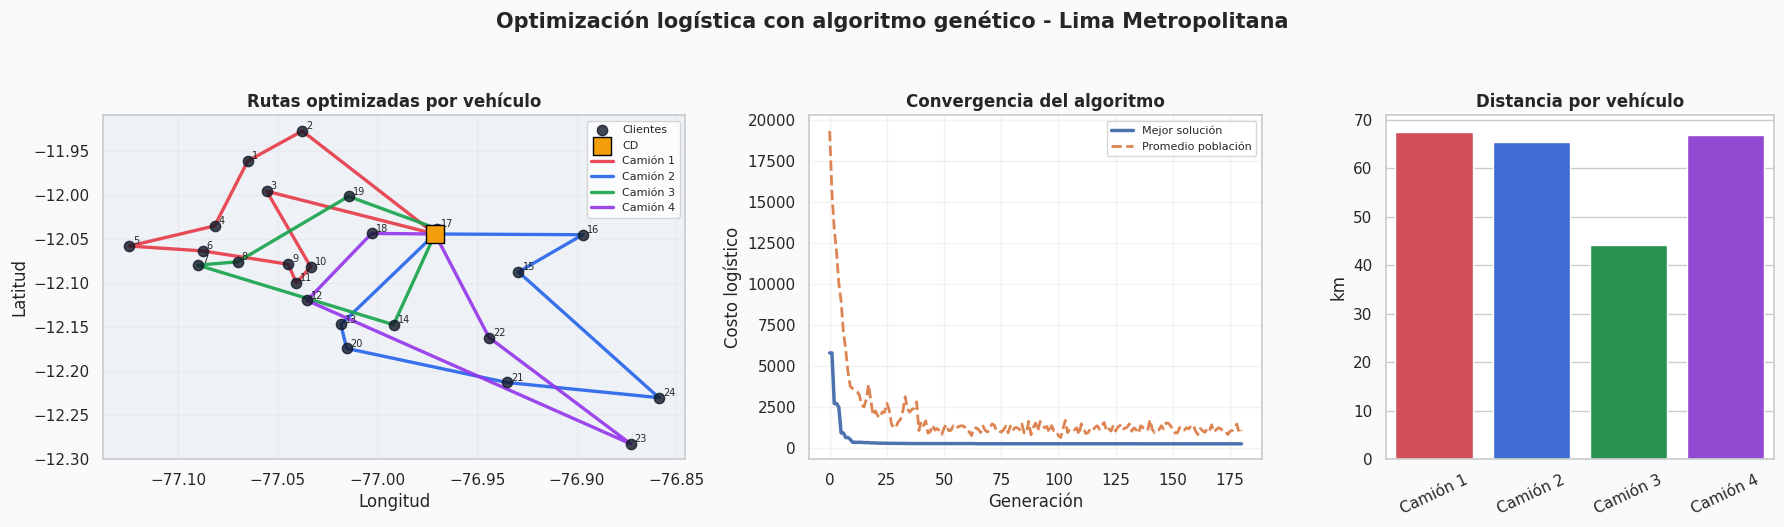

In [69]:
# ============================================================
# 12. VISUALIZACIONES PROFESIONALES
# ============================================================

PALETA_VEHICULOS = ["#E63946", "#2563EB", "#16A34A", "#9333EA"]


def plot_dashboard_final():
    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        gridspec_kw={"width_ratios": [1.35, 1.05, 0.9]}
    )

    fig.patch.set_facecolor("#F8FAFC")

    ax_mapa, ax_conv, ax_bar = axes

    ax_mapa.set_facecolor("#EEF2F7")

    ax_mapa.scatter(
        clientes["lon"],
        clientes["lat"],
        s=55,
        color="#111827",
        alpha=0.8,
        label="Clientes",
        zorder=3
    )

    ax_mapa.scatter(
        deposito["lon"],
        deposito["lat"],
        s=180,
        marker="s",
        color="#F59E0B",
        edgecolor="black",
        linewidth=1,
        label="CD",
        zorder=4
    )

    for i, fila in clientes.iterrows():
        ax_mapa.text(
            fila["lon"] + 0.002,
            fila["lat"] + 0.002,
            str(i + 1),
            fontsize=7
        )

    for v, ruta in enumerate(rutas_finales):
        puntos_lon = [deposito["lon"]]
        puntos_lat = [deposito["lat"]]

        for cliente_id in ruta:
            puntos_lon.append(clientes.loc[cliente_id, "lon"])
            puntos_lat.append(clientes.loc[cliente_id, "lat"])

        puntos_lon.append(deposito["lon"])
        puntos_lat.append(deposito["lat"])

        ax_mapa.plot(
            puntos_lon,
            puntos_lat,
            linewidth=2.4,
            color=PALETA_VEHICULOS[v],
            alpha=0.9,
            label=vehiculos.loc[v, "vehiculo"]
        )

    ax_mapa.set_title("Rutas optimizadas por vehículo", fontsize=12, fontweight="bold")
    ax_mapa.set_xlabel("Longitud")
    ax_mapa.set_ylabel("Latitud")
    ax_mapa.legend(fontsize=8)
    ax_mapa.grid(alpha=0.2)

    sns.lineplot(
        data=historial_df,
        x="generacion",
        y="mejor_costo",
        ax=ax_conv,
        linewidth=2.5,
        label="Mejor solución"
    )

    sns.lineplot(
        data=historial_df,
        x="generacion",
        y="costo_promedio",
        ax=ax_conv,
        linewidth=2,
        linestyle="--",
        label="Promedio población"
    )

    ax_conv.set_title("Convergencia del algoritmo", fontsize=12, fontweight="bold")
    ax_conv.set_xlabel("Generación")
    ax_conv.set_ylabel("Costo logístico")
    ax_conv.legend(fontsize=8)
    ax_conv.grid(alpha=0.25)

    sns.barplot(
        data=resumen_rutas_df,
        x="vehiculo",
        y="distancia_km",
        ax=ax_bar,
        palette=PALETA_VEHICULOS
    )

    ax_bar.set_title("Distancia por vehículo", fontsize=12, fontweight="bold")
    ax_bar.set_xlabel("")
    ax_bar.set_ylabel("km")
    ax_bar.tick_params(axis="x", rotation=25)

    plt.suptitle(
        "Optimización logística con algoritmo genético - Lima Metropolitana",
        fontsize=15,
        fontweight="bold",
        y=1.05
    )

    plt.tight_layout()
    plt.show()


plot_dashboard_final()

In [70]:
# ============================================================
# 13. MAPA INTERACTIVO EN FOLIUM
# ============================================================

def crear_mapa_interactivo(rutas, output_path):
    mapa = folium.Map(
        location=[deposito["lat"], deposito["lon"]],
        zoom_start=11,
        tiles="CartoDB positron"
    )

    folium.Marker(
        [deposito["lat"], deposito["lon"]],
        popup=f"<b>{deposito['nombre']}</b><br>{deposito['direccion']}",
        icon=folium.Icon(color="black", icon="home")
    ).add_to(mapa)

    colores_folium = ["red", "blue", "green", "purple"]

    for vehiculo_idx, ruta in enumerate(rutas):
        puntos = [[deposito["lat"], deposito["lon"]]]

        for cliente_id in ruta:
            fila = clientes.loc[cliente_id]
            puntos.append([fila["lat"], fila["lon"]])

            popup = f"""
            <b>{fila['cliente']}</b><br>
            Dirección: {fila['direccion']}<br>
            Distrito: {fila['distrito']}<br>
            Carga: {fila['tipo_carga']}<br>
            Demanda: {fila['demanda_m3']} m³<br>
            Prioridad: {fila['prioridad']}<br>
            Ventana: {fila['ventana']}<br>
            Vehículo: {vehiculos.loc[vehiculo_idx, 'vehiculo']}<br>
            Placa: {vehiculos.loc[vehiculo_idx, 'placa']}
            """

            folium.CircleMarker(
                location=[fila["lat"], fila["lon"]],
                radius=6,
                popup=popup,
                color=colores_folium[vehiculo_idx],
                fill=True,
                fill_opacity=0.85
            ).add_to(mapa)

        puntos.append([deposito["lat"], deposito["lon"]])

        folium.PolyLine(
            puntos,
            color=colores_folium[vehiculo_idx],
            weight=4,
            opacity=0.75,
            tooltip=f"{vehiculos.loc[vehiculo_idx, 'vehiculo']} - {vehiculos.loc[vehiculo_idx, 'placa']}"
        ).add_to(mapa)

    mapa.save(output_path)
    return mapa


mapa_path = os.path.join(OUTPUT_DIR, "mapa_rutas_lima_vrp.html")
mapa = crear_mapa_interactivo(rutas_finales, mapa_path)
display(mapa)

In [71]:
# ============================================================
# 14. FUNCIÓN PARA FRAMES DE VIDEO Y GIF
# ============================================================

def metricas_generacion(cromosoma):
    rutas = decodificar_cromosoma(cromosoma)

    distancia_total = 0
    penalizacion_total = 0
    carga_total = 0
    atraso_total = 0

    for vehiculo_idx, ruta in enumerate(rutas):
        _, detalle = evaluar_ruta(ruta, vehiculo_idx)

        distancia_total += detalle["distancia"]
        penalizacion_total += detalle["penalizacion"]
        carga_total += detalle["carga"]
        atraso_total += detalle["atraso_total"]

    return rutas, distancia_total, penalizacion_total, carga_total, atraso_total


def crear_frame(cromosoma, gen, filename):
    rutas, distancia_total, penalizacion_total, carga_total, atraso_total = metricas_generacion(cromosoma)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        gridspec_kw={"width_ratios": [1.45, 1.1, 0.85]}
    )

    fig.patch.set_facecolor("#F8FAFC")

    ax_mapa, ax_conv, ax_info = axes

    ax_mapa.set_facecolor("#EEF2F7")

    ax_mapa.scatter(
        clientes["lon"],
        clientes["lat"],
        s=50,
        color="#111827",
        alpha=0.8,
        zorder=3
    )

    ax_mapa.scatter(
        deposito["lon"],
        deposito["lat"],
        s=170,
        marker="s",
        color="#F59E0B",
        edgecolor="black",
        linewidth=1,
        zorder=4
    )

    for i, fila in clientes.iterrows():
        ax_mapa.text(
            fila["lon"] + 0.002,
            fila["lat"] + 0.002,
            str(i + 1),
            fontsize=7
        )

    for v, ruta in enumerate(rutas):
        puntos_lon = [deposito["lon"]]
        puntos_lat = [deposito["lat"]]

        for cliente_id in ruta:
            puntos_lon.append(clientes.loc[cliente_id, "lon"])
            puntos_lat.append(clientes.loc[cliente_id, "lat"])

        puntos_lon.append(deposito["lon"])
        puntos_lat.append(deposito["lat"])

        ax_mapa.plot(
            puntos_lon,
            puntos_lat,
            linewidth=2.3,
            alpha=0.9,
            color=PALETA_VEHICULOS[v],
            label=vehiculos.loc[v, "vehiculo"]
        )

    ax_mapa.set_title("Mejor ruta encontrada", fontsize=12, fontweight="bold")
    ax_mapa.set_xlabel("Longitud", fontsize=9)
    ax_mapa.set_ylabel("Latitud", fontsize=9)
    ax_mapa.legend(fontsize=7)
    ax_mapa.grid(alpha=0.22)

    ax_conv.plot(
        historial_df["generacion"][:gen + 1],
        historial_df["mejor_costo"][:gen + 1],
        linewidth=2.6,
        color="#2563EB",
        label="Mejor solución"
    )

    ax_conv.plot(
        historial_df["generacion"][:gen + 1],
        historial_df["costo_promedio"][:gen + 1],
        linewidth=1.8,
        linestyle="--",
        color="#F97316",
        label="Promedio población"
    )

    ax_conv.scatter(
        gen,
        historial_df.loc[gen, "mejor_costo"],
        s=60,
        color="#2563EB",
        edgecolor="white",
        linewidth=1.2,
        zorder=5
    )

    ax_conv.set_xlim(0, CONFIG["generaciones"])
    ax_conv.set_title("Convergencia", fontsize=12, fontweight="bold")
    ax_conv.set_xlabel("Generación", fontsize=9)
    ax_conv.set_ylabel("Costo logístico", fontsize=9)
    ax_conv.legend(fontsize=8)
    ax_conv.grid(alpha=0.25)

    ax_info.axis("off")

    mejora = (
        1
        - historial_df.loc[gen, "mejor_costo"]
        / historial_df.loc[0, "mejor_costo"]
    ) * 100

    texto = f"""
GENERACIÓN
{gen} / {CONFIG["generaciones"]}

MEJOR COSTO
{historial_df.loc[gen, "mejor_costo"]:,.1f}

PROMEDIO POBLACIÓN
{historial_df.loc[gen, "costo_promedio"]:,.1f}

DISTANCIA TOTAL
{distancia_total:,.1f} km

PENALIZACIÓN
{penalizacion_total:,.1f}

CARGA ASIGNADA
{carga_total:,.1f} m³

ATRASO TOTAL
{atraso_total:,.1f} min

MEJORA
{mejora:.1f} %
"""

    ax_info.text(
        0.03,
        0.97,
        texto,
        transform=ax_info.transAxes,
        va="top",
        fontsize=10.8,
        family="monospace",
        bbox=dict(
            facecolor="white",
            edgecolor="#CBD5E1",
            boxstyle="round,pad=0.65"
        )
    )

    fig.suptitle(
        "Algoritmo genético para optimización de rutas de reparto en Lima",
        fontsize=15,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches="tight")
    plt.close()

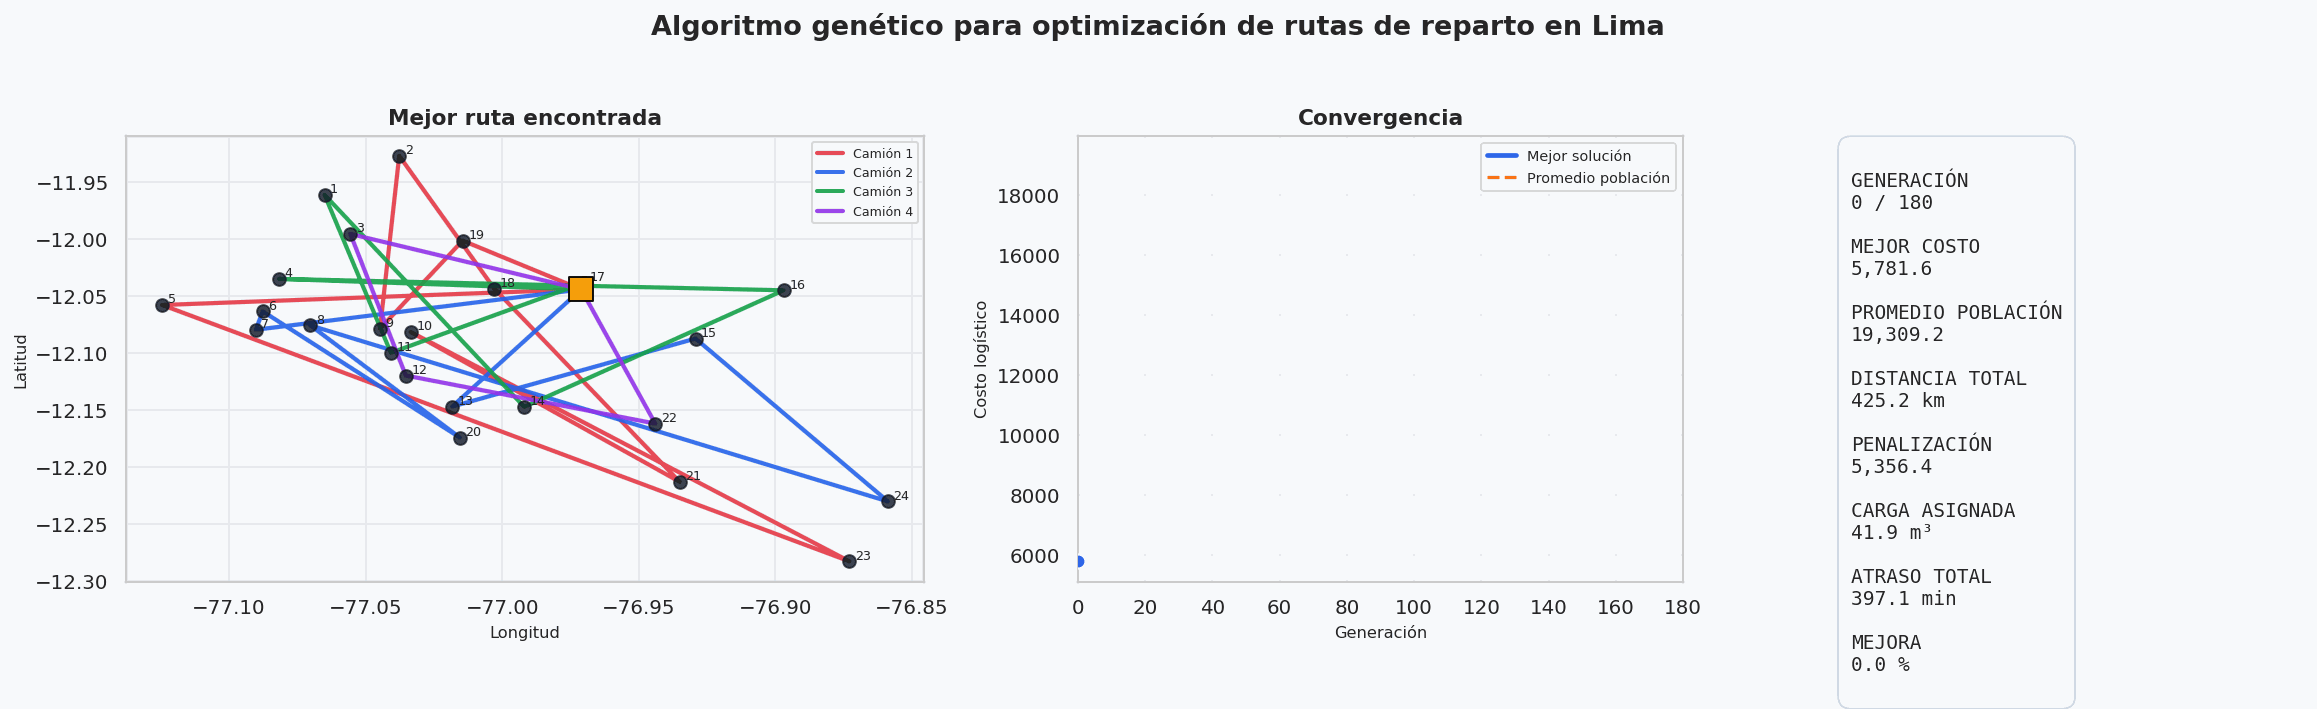

GIF generado: resultados_vrp_lima/evolucion_algoritmo_genetico_vrp_lima.gif
Video generado: resultados_vrp_lima/evolucion_algoritmo_genetico_vrp_lima.mp4


In [72]:
# ============================================================
# 15. GENERAR GIF Y VIDEO MP4
# ============================================================

frames_generaciones = list(
    range(0, CONFIG["generaciones"] + 1, CONFIG["frame_step"])
)

frame_paths = []

for gen in frames_generaciones:
    frame_path = os.path.join(FRAME_DIR, f"frame_{gen:04d}.png")
    crear_frame(mejores_cromosomas[gen], gen, frame_path)
    frame_paths.append(frame_path)

imagenes = [imageio.imread(path) for path in frame_paths]

gif_path = os.path.join(OUTPUT_DIR, "evolucion_algoritmo_genetico_vrp_lima.gif")
video_path = os.path.join(OUTPUT_DIR, "evolucion_algoritmo_genetico_vrp_lima.mp4")

imageio.mimsave(gif_path, imagenes, duration=0.18)

imageio.mimsave(
    video_path,
    imagenes,
    fps=CONFIG["fps_video"],
    macro_block_size=16
)

display(Image(filename=gif_path))
display(Video(video_path, embed=True))

print(f"GIF generado: {gif_path}")
print(f"Video generado: {video_path}")

In [73]:
# ============================================================
# 16. EXPORTAR RESULTADOS
# ============================================================

historial_path = os.path.join(OUTPUT_DIR, "historial_convergencia.csv")
resumen_path = os.path.join(OUTPUT_DIR, "resumen_rutas.csv")
detalle_path = os.path.join(OUTPUT_DIR, "detalle_entregas.csv")

historial_df.to_csv(historial_path, index=False)
resumen_rutas_df.to_csv(resumen_path, index=False)
detalle_entregas_df.to_csv(detalle_path, index=False)

print("Archivos exportados:")
print(historial_path)
print(resumen_path)
print(detalle_path)
print(mapa_path)
print(gif_path)
print(video_path)

Archivos exportados:
resultados_vrp_lima/historial_convergencia.csv
resultados_vrp_lima/resumen_rutas.csv
resultados_vrp_lima/detalle_entregas.csv
resultados_vrp_lima/mapa_rutas_lima_vrp.html
resultados_vrp_lima/evolucion_algoritmo_genetico_vrp_lima.gif
resultados_vrp_lima/evolucion_algoritmo_genetico_vrp_lima.mp4


In [74]:
# ============================================================
# 17. RESUMEN EJECUTIVO FINAL
# ============================================================

costo_inicial = historial_df["mejor_costo"].iloc[0]
costo_final = historial_df["mejor_costo"].iloc[-1]
mejora = (1 - costo_final / costo_inicial) * 100

distancia_total_final = resumen_rutas_df["distancia_km"].sum()
penalizacion_total_final = resumen_rutas_df["penalizacion"].sum()
atraso_total_final = resumen_rutas_df["atraso_total_min"].sum()

print("=" * 60)
print("RESUMEN EJECUTIVO")
print("=" * 60)
print(f"Clientes atendidos: {CONFIG['n_clientes']}")
print(f"Vehículos disponibles: {CONFIG['n_vehiculos']}")
print(f"Población: {CONFIG['poblacion']}")
print(f"Generaciones: {CONFIG['generaciones']}")
print(f"Costo inicial: {costo_inicial:,.2f}")
print(f"Costo final: {costo_final:,.2f}")
print(f"Mejora obtenida: {mejora:.2f}%")
print(f"Distancia total final: {distancia_total_final:,.2f} km")
print(f"Penalización final: {penalizacion_total_final:,.2f}")
print(f"Atraso total final: {atraso_total_final:,.2f} min")
print("-" * 60)
print("Restricciones consideradas:")
print("- Capacidad por vehículo")
print("- Ventanas horarias")
print("- Incompatibilidad entre tipos de carga")
print("- Penalización por atraso")
print("- Tiempo de servicio por cliente")
print("- Hora máxima de retorno al centro de distribución")
print("=" * 60)

RESUMEN EJECUTIVO
Clientes atendidos: 24
Vehículos disponibles: 4
Población: 140
Generaciones: 180
Costo inicial: 5,781.56
Costo final: 244.02
Mejora obtenida: 95.78%
Distancia total final: 244.01 km
Penalización final: 0.00
Atraso total final: 0.00 min
------------------------------------------------------------
Restricciones consideradas:
- Capacidad por vehículo
- Ventanas horarias
- Incompatibilidad entre tipos de carga
- Penalización por atraso
- Tiempo de servicio por cliente
- Hora máxima de retorno al centro de distribución
